# Section 1 — Kuantum Makine Öğrenmesine Giriş

Bu notebook’un amacı, Kuantum Makine Öğrenmesi’ni yalnızca teorik bir kavram olarak değil, aynı zamanda klasik makine öğrenmesi iş akışı içinde uygulanabilir bir modelleme yaklaşımı olarak ele almaktır.

Kuantum Makine Öğrenmesi, klasik makine öğrenmesi problemlerini tamamen ortadan kaldırmaz. Bunun yerine, klasik bir öğrenme görevine kuantum bileşenler ekler.

Genel fikir şu şekildedir:

$$
\text{Veri} \rightarrow \text{Ön İşleme} \rightarrow \text{Temsil / Model} \rightarrow \text{Tahmin} \rightarrow \text{Değerlendirme}
$$

QML’de değişen kısım genellikle temsil veya model aşamasıdır. Veri hâlâ klasik olabilir, çıktı hâlâ klasik olabilir; fakat arada kuantum devreleri, kuantum kernel yöntemleri veya kuantum ölçümleri kullanılabilir.

## 1.1 Makine Öğrenmesi Nedir?

Makine öğrenmesi, verilerden örüntüler öğrenerek tahmin, karar veya örnek üretme amacı taşıyan yöntemler bütünüdür.

Bir makine öğrenmesi problemi kurarken temel sıra şudur:

1. Görev tanımlanır.
2. Girdi ve çıktı belirlenir.
3. Uygun model ailesi seçilir.
4. Model eğitilir.
5. Model daha önce görmediği veriler üzerinde değerlendirilir.

Basitçe:

$$
\hat{y} = f_{\theta}(x)
$$

Burada:

- $x$: giriş verisi,
- $\theta$: modelin öğrenilebilir parametreleri,
- $f_{\theta}$: model fonksiyonu,
- $\hat{y}$: modelin tahmini çıktısıdır.

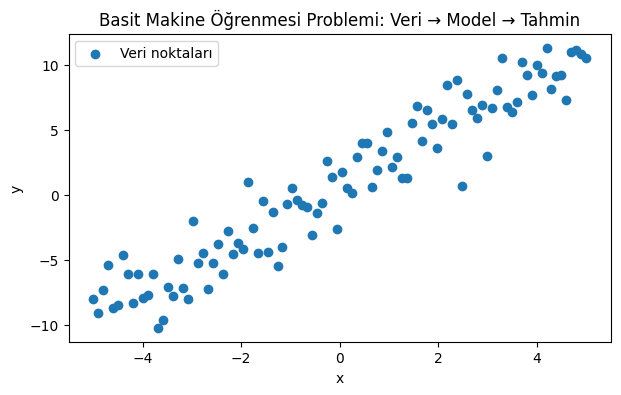

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Basit bir yapay veri oluşturalım
np.random.seed(42)

x = np.linspace(-5, 5, 100)
y = 2 * x + 1 + np.random.normal(0, 2, size=x.shape)

plt.figure(figsize=(7, 4))
plt.scatter(x, y, label="Veri noktaları")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Basit Makine Öğrenmesi Problemi: Veri → Model → Tahmin")
plt.legend()
plt.show()

## 1.2 Kuantum Makine Öğrenmesi Nedir?

Kuantum Makine Öğrenmesi, klasik öğrenme problemlerinin içine kuantum hesaplama bileşenleri ekleyen bir yaklaşımdır.

QML’de öğrenme hedefi çoğu zaman klasik kalır:

$$
x \mapsto \hat{y}
$$

Fakat modelin içinde kuantum bir işlem bulunabilir:

$$
x \rightarrow |\psi(x)\rangle \rightarrow U(\theta) \rightarrow \text{measurement} \rightarrow \hat{y}
$$

Burada:

- $x$: klasik veri,
- $|\psi(x)\rangle$: verinin kuantum durumu olarak temsil edilmesi,
- $U(\theta)$: parametreli kuantum devresi,
- $\theta$: öğrenilebilir kuantum devre parametreleri,
- measurement: ölçüm işlemi,
- $\hat{y}$: klasik çıktı veya tahmin değeridir.

## 1.3 Hibrit QML Pipeline

Yakın dönem QML uygulamaları çoğunlukla hibrit yapıdadır. Yani klasik ve kuantum bileşenler birlikte çalışır.

Genel hibrit yapı:

$$
\text{Klasik Veri}
\rightarrow
\text{Kuantum Encoding}
\rightarrow
\text{Parametreli Kuantum Devresi}
\rightarrow
\text{Ölçüm}
\rightarrow
\text{Klasik Optimizasyon}
$$

Bu yapıda kuantum bilgisayar veya simülatör, modelin yalnızca belirli bir kısmını oluşturur. Veri bölme, ölçekleme, metrik seçimi, validasyon ve test gibi adımlar hâlâ klasik makine öğrenmesindeki kadar önemlidir.

In [2]:
# QML pipeline'ını basitçe temsil eden bir sözlük oluşturalım

qml_pipeline = {
    "1. Veri": "Klasik veri seti",
    "2. Ön İşleme": "Normalize etme, ölçekleme, train-test split",
    "3. Encoding": "Klasik veriyi kuantum duruma çevirme",
    "4. Kuantum Model": "Parametreli kuantum devresi",
    "5. Ölçüm": "Kuantum çıktıdan klasik bilgi elde etme",
    "6. Optimizasyon": "Parametreleri klasik optimizer ile güncelleme",
    "7. Değerlendirme": "Accuracy, F1, MSE gibi metrikler"
}

for step, description in qml_pipeline.items():
    print(f"{step}: {description}")

1. Veri: Klasik veri seti
2. Ön İşleme: Normalize etme, ölçekleme, train-test split
3. Encoding: Klasik veriyi kuantum duruma çevirme
4. Kuantum Model: Parametreli kuantum devresi
5. Ölçüm: Kuantum çıktıdan klasik bilgi elde etme
6. Optimizasyon: Parametreleri klasik optimizer ile güncelleme
7. Değerlendirme: Accuracy, F1, MSE gibi metrikler


## 1.4 QML Neden Otomatik Avantaj Sağlamaz?

Bir modelin içinde kuantum devre bulunması, o modelin otomatik olarak daha iyi olduğu anlamına gelmez.

QML yaklaşımının anlamlı olabilmesi için şu sorular cevaplanmalıdır:

- Bu problem için güçlü bir klasik baseline var mı?
- Kullanılan metrik doğru seçilmiş mi?
- Veri sızıntısı engellenmiş mi?
- Kuantum modelin neden faydalı olabileceğine dair teknik bir hipotez var mı?
- Karşılaştırma adil mi?

Bu nedenle QML’de amaç yalnızca “kuantum kullandım” demek değildir. Amaç, belirli bir problemde kuantum temsilin veya kuantum modelin gerçekten ek değer sağlayıp sağlamadığını test etmektir.

## 1.5 Klasik ve Kuantum Pipeline Karşılaştırması

Klasik makine öğrenmesi pipeline’ı:

$$
X_{\text{train}}
\rightarrow
\text{Preprocessing}
\rightarrow
f_{\theta}(x)
\rightarrow
\hat{y}
\rightarrow
\text{Metric}
$$

Hibrit QML pipeline’ı:

$$
X_{\text{train}}
\rightarrow
\text{Preprocessing}
\rightarrow
|\psi(x)\rangle
\rightarrow
U(\theta)
\rightarrow
\text{Measurement}
\rightarrow
\hat{y}
\rightarrow
\text{Metric}
$$

İki pipeline arasındaki temel fark, model veya temsil aşamasında ortaya çıkar. Bunun dışındaki deneysel disiplin aynıdır.

In [3]:
import pandas as pd

comparison = pd.DataFrame({
    "Aşama": [
        "Veri",
        "Ön işleme",
        "Temsil",
        "Model",
        "Çıktı",
        "Değerlendirme"
    ],
    "Klasik ML": [
        "Klasik veri",
        "Klasik preprocessing",
        "Klasik feature vektörü",
        "Klasik model",
        "Tahmin / skor",
        "Klasik metrikler"
    ],
    "Hibrit QML": [
        "Genellikle klasik veri",
        "Klasik preprocessing",
        "Kuantum encoding",
        "Parametreli kuantum devresi",
        "Ölçüm sonucu klasik çıktı",
        "Klasik metrikler"
    ]
})

comparison

,Aşama,Klasik ML,Hibrit QML
0,Veri,Klasik veri,Genellikle klasik veri
1,Ön işleme,Klasik preprocessing,Klasik preprocessing
2,Temsil,Klasik feature vektörü,Kuantum encoding
3,Model,Klasik model,Parametreli kuantum devresi
4,Çıktı,Tahmin / skor,Ölçüm sonucu klasik çıktı
5,Değerlendirme,Klasik metrikler,Klasik metrikler


## 1.6 Bu Notebook’ta İzlenecek Yaklaşım

Bu giriş notebook’unda QML’i doğrudan karmaşık kuantum avantaj iddiaları üzerinden değil, sağlam bir makine öğrenmesi iş akışı üzerinden inceleyeceğiz.

İzlenecek yaklaşım:

1. Önce klasik ML problemi kurulacak.
2. Güçlü ve anlaşılır bir baseline oluşturulacak.
3. Veri bölme ve ön işleme dikkatli yapılacak.
4. Daha sonra küçük bir kuantum model eklenecek.
5. Klasik baseline ile QML modeli aynı protokolde karşılaştırılacak.

Bu yaklaşım sayesinde QML modeli yalnızca ilginç olduğu için değil, gerçekten test edilebilir bir modelleme alternatifi olduğu için incelenmiş olacak.

# Section 2 — Makine Öğrenmesi Temelleri

Kuantum Makine Öğrenmesi’ni doğru anlamak için önce klasik makine öğrenmesi disiplinini doğru kurmak gerekir.

Bu bölümde şu kavramları ele alacağız:

- Train / Validation / Test ayrımı
- Veri sızıntısı (data leakage)
- Metrik seçimi
- Baseline model oluşturma

Bu adımlar QML’de de aynen geçerlidir. Kuantum bileşen eklemek bu temel disiplinleri ortadan kaldırmaz.

## 2.1 Train / Validation / Test Ayrımı

Bir modeli doğru değerlendirebilmek için veri üçe ayrılır:

- **Train set**: Model parametrelerinin öğrenildiği veri
- **Validation set**: Model seçimi ve hyperparameter tuning için kullanılır
- **Test set**: Final performans ölçümü (asla eğitimde kullanılmaz)

Genel yapı:

$$
\text{Dataset} \rightarrow \text{Train} + \text{Validation} + \text{Test}
$$

Amaç:

- Modelin ezberlemesini (overfitting) önlemek
- Gerçek dünyadaki performansı doğru tahmin etmek

In [4]:
from sklearn.model_selection import train_test_split
import numpy as np

# Yapay veri
np.random.seed(42)
X = np.random.randn(200, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

# Train + temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Validation + Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (120, 2)
Validation: (40, 2)
Test: (40, 2)


## 2.2 Neden Üç Ayrım Gerekli?

Eğer validation set olmazsa:

- Model seçimi sırasında test verisi kullanılır
- Bu da test performansını yapay olarak şişirir

Eğer test set olmazsa:

- Gerçek genelleme performansı ölçülemez

Bu yüzden:

- Train → öğrenme
- Validation → karar verme
- Test → final değerlendirme

olarak ayrım yapılmalıdır.

## 2.3 Veri Sızıntısı (Data Leakage)

Data leakage, modelin eğitim sırasında aslında görmemesi gereken bilgileri dolaylı olarak öğrenmesidir.

Yanlış yaklaşım:

1. Tüm veriyi normalize et
2. Sonra train/test ayır

Doğru yaklaşım:

1. Önce train/test ayır
2. Normalizasyonu sadece train üzerinde öğren
3. Aynı dönüşümü test'e uygula

Matematiksel olarak:

$$
X_{\text{scaled}} = \frac{X - \mu_{\text{train}}}{\sigma_{\text{train}}}
$$

Burada ortalama ve standart sapma yalnızca train setten hesaplanır.

In [6]:
from sklearn.preprocessing import StandardScaler

# HATALI (leakage var)
scaler_wrong = StandardScaler()
X_scaled_wrong = scaler_wrong.fit_transform(X)  # tüm veri kullanıldı!

# DOĞRU
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Leakage'siz scaling tamamlandı.")

Leakage'siz scaling tamamlandı.


## 2.4 Metrik Seçimi

Tek bir “en iyi metrik” yoktur. Metrik, probleme göre seçilir.

### Sınıflandırma için:

- Accuracy
- Precision / Recall
- F1 Score

### Regresyon için:

- MAE (Mean Absolute Error)
- MSE (Mean Squared Error)

Örnek:

$$
\text{Accuracy} = \frac{\text{Doğru Tahmin Sayısı}}{\text{Toplam Tahmin}}
$$

$$
\text{MSE} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
$$

MSE büyük hataları daha fazla cezalandırır, MAE daha dengelidir.

In [7]:
from sklearn.metrics import accuracy_score, f1_score

# Basit tahmin simülasyonu
y_pred = np.random.randint(0, 2, size=len(y_test))

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", acc)
print("F1 Score:", f1)

Accuracy: 0.375
F1 Score: 0.1935483870967742


## 2.5 Baseline Model Nedir?

Baseline model, problemi çözmek için kullanılan en basit ama anlamlı referans modeldir.

QML kullanmadan önce şu soruya cevap verilmelidir:

> "Klasik yöntemle ne kadar iyi sonuç alabiliyorum?"

Bu referans olmadan QML performansı yorumlanamaz.

Bu notebook’ta baseline olarak Logistic Regression kullanacağız.

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

y_val_pred = model.predict(X_val_scaled)

val_acc = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy (Baseline):", val_acc)

Validation Accuracy (Baseline): 1.0


## 2.6 Baseline Neden Önemli?

Baseline model şu durumları ayırt etmemizi sağlar:

- Model kötü → pipeline hatalı olabilir
- Model kötü → problem lineer olmayabilir
- Model iyi → QML'e gerek olmayabilir

Bu yüzden QML'e geçmeden önce:

✔ Güçlü baseline  
✔ Doğru metrik  
✔ Leakage-free pipeline  

zorunludur.

## 2.7 Bu Bölümün Özeti

- Train / Validation / Test ayrımı kritik öneme sahiptir
- Data leakage model performansını sahte şekilde artırır
- Metrik seçimi probleme göre yapılmalıdır
- Baseline model olmadan QML değerlendirmesi anlamsızdır

Bir sonraki bölümde kuantum tarafına daha yakından bakacağız:

➡️ **Section 3 — QML Temelleri (Encoding, Measurement, Quantum Output)**

# Section 3 — QML Temelleri

Bu bölümde kuantum makine öğrenmesinin en kritik üç bileşenini ele alacağız:

- Encoding (veriyi kuantum duruma çevirme)
- Quantum model (parametreli kuantum devresi)
- Measurement (klasik çıktıya dönüş)

Ama önemli nokta:

QML, klasik ML pipeline’ını değiştirmez — sadece modelin iç yapısını değiştirir.

## 3.1 Encoding (Veri → Kuantum Durum)

Klasik veri doğrudan kuantum devreye girmez. Önce kuantum duruma çevrilir:

$$
x \rightarrow |\psi(x)\rangle
$$

Bu işleme encoding denir.

Örnek:

Bir özellik değeri $x$ bir rotation gate ile encode edilebilir:

$$
|\psi(x)\rangle = R_y(x) |0\rangle
$$

Encoding seçimi modelin başarısını doğrudan etkiler.

In [10]:
import pennylane as qml
from pennylane import numpy as np

dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev)
def encoding_circuit(x):
    qml.RY(x, wires=0)
    return qml.state()

encoding_circuit(0.5)

array([0.96891242+0.j, 0.24740396+0.j])

## 3.2 Parametreli Kuantum Model

Encoding sonrası veri, parametreli bir kuantum devresinden geçirilir:

$$
|\psi(x)\rangle \rightarrow U(\theta) |\psi(x)\rangle
$$

Burada:

- $\theta$: öğrenilebilir parametrelerdir
- $U(\theta)$: kuantum modelidir

Bu yapı klasik sinir ağlarına benzer:

- Encoding → input layer
- Quantum circuit → hidden layer
- Measurement → output layer

In [11]:
@qml.qnode(dev)
def variational_circuit(x, theta):
    qml.RY(x, wires=0)       # encoding
    qml.RZ(theta, wires=0)   # trainable parametre
    return qml.expval(qml.PauliZ(0))

variational_circuit(0.5, 0.1)

np.float64(0.8775825618903726)

## 3.3 Measurement (Kuantum → Klasik Çıkış)

Kuantum devre doğrudan sınıf etiketi üretmez.

Önce sürekli bir değer üretir:

$$
\hat{y}_{quantum} \in [-1, 1]
$$

Bu değer:

- expectation value olabilir
- probability olabilir

Sonra threshold uygulanır:

$$
\hat{y} =
\begin{cases}
1, & \hat{y}_{quantum} > 0 \\
0, & \text{aksi halde}
\end{cases}
$$

Yani kuantum model → skor üretir  
klasik post-processing → karar üretir

In [12]:
def predict(x, theta):
    val = variational_circuit(x, theta)
    return 1 if val > 0 else 0

predict(0.5, 0.1)

1

## 3.4 Encoding vs Trainable Parametre

İki önemli bileşen vardır:

- $x$ → her örnek için değişir
- $\theta$ → tüm veri için ortak öğrenilir

Bu ayrım çok kritiktir:

- Encoding → veri temsilidir
- Parametreler → modelin öğrenme kapasitesidir

Yanlış encoding → model öğrenemez  
yetersiz parametre → model esnek olmaz

## 3.5 Differentiable Quantum Circuit

QML’de amaç:

$$
\theta \rightarrow \text{loss}(\theta)
$$

ilişkisinin öğrenilebilir olmasıdır.

Bu yüzden devre:

- sürekli değişmeli
- optimize edilebilir olmalıdır

Bu özellik "differentiability" olarak adlandırılır.

In [14]:
theta = 0.1
lr = 0.1

# basit loss (dummy)
def loss(theta):
    preds = [variational_circuit(x, theta) for x in X_train[:,0]]
    return np.mean(preds)

for i in range(10):
    grad = (loss(theta + 0.01) - loss(theta)) / 0.01
    theta = theta - lr * grad

theta

np.float64(0.09999999999999779)

## 3.6 Önemli Nokta

QML model:

- doğrudan label üretmez
- önce skor üretir
- sonra klasik yöntemlerle karar verir

Bu yapı Logistic Regression ile benzerdir:

- model → probability üretir
- threshold → sınıf üretir

## 3.7 Measurement Çıktısını Görselleştirme

Kuantum model doğrudan sınıf etiketi üretmez.

Önce sürekli bir değer üretir:

$$
f_{\theta}(x) \in [-1, 1]
$$

Bu değer:

- expectation value olabilir
- probability olabilir

Bu çıktıyı görselleştirmek önemlidir çünkü:

- modelin nasıl davrandığını anlamamızı sağlar
- decision boundary’yi ortaya çıkarır

Şimdi bu sürekli çıktıyı grafikte inceleyelim.

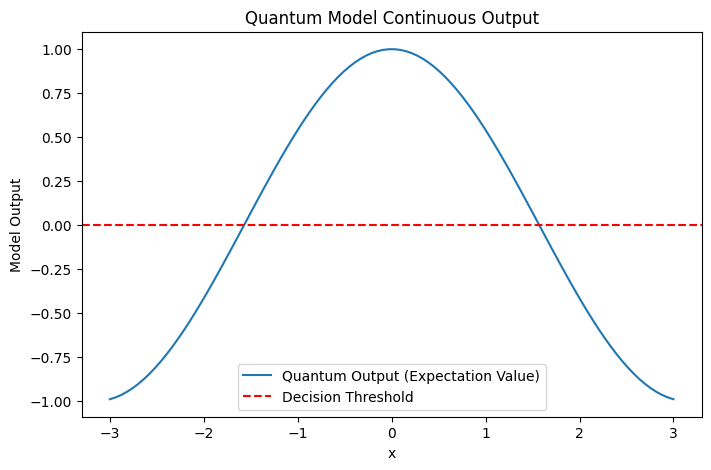

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# x değerleri
x_vals = np.linspace(-3, 3, 100)

# sabit theta
theta = 0.5

# model çıktısı
y_vals = [variational_circuit(x, theta) for x in x_vals]

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label="Quantum Output (Expectation Value)")
plt.axhline(0, linestyle="--", color="red", label="Decision Threshold")
plt.xlabel("x")
plt.ylabel("Model Output")
plt.title("Quantum Model Continuous Output")
plt.legend()
plt.show()

### Yorum

Grafikte görüldüğü gibi:

- Model sürekli bir çıktı üretir
- Çıktı -1 ile 1 arasındadır
- Sınıflandırma için doğrudan kullanılamaz

Bu yüzden threshold uygulanır.

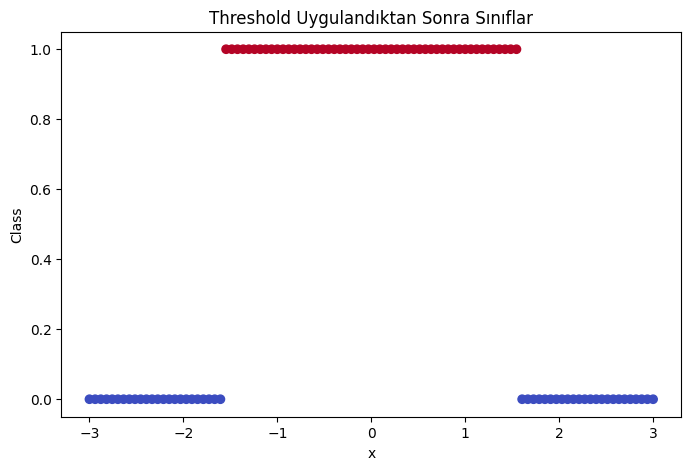

In [17]:
y_class = [1 if y > 0 else 0 for y in y_vals]

plt.figure(figsize=(8,5))
plt.scatter(x_vals, y_class, c=y_class, cmap="coolwarm")
plt.xlabel("x")
plt.ylabel("Class")
plt.title("Threshold Uygulandıktan Sonra Sınıflar")
plt.show()

## 3.8 Decision Boundary

Decision boundary, modelin sınıf değiştirdiği noktadır.

Matematiksel olarak:

$$
f_{\theta}(x) = 0
$$

Bu nokta:

- sınıf 0 → sınıf 1 geçişidir
- modelin öğrendiği sınırdır

## 3.9 Önemli İçgörü

Bu görselleştirme bize şunu gösterir:

✔ Kuantum model = sürekli fonksiyon  
✔ Sınıflandırma = sonradan yapılan işlem  

Yani:

$$
\text{Quantum Model} \neq \text{Classifier}
$$

Doğrusu:

$$
\text{Classifier} = \text{Quantum Model} + \text{Threshold}
$$

---

Bu yapı klasik logistic regression ile birebir aynıdır:

- model → probability üretir
- threshold → class üretir

---

## 3.10 Neden Bu Önemli?

Çünkü:

- QML’i yanlış anlayanlar doğrudan "quantum classifier" bekler
- ama aslında quantum model sadece bir skor üretir

Bu fark anlaşılmazsa:

❌ yanlış model yorumlama  
❌ yanlış metrik seçimi  
❌ yanlış karşılaştırma  

kaçınılmaz olur

# Section 4 — Genel Değerlendirme ve Sonuç

Bu noktaya kadar:

- Klasik makine öğrenmesi pipeline’ını kurduk
- Baseline model oluşturduk
- Kuantum modeli tanımladık
- Measurement sonrası çıktıyı analiz ettik
- Continuous output → threshold → class dönüşümünü görselleştirdik

Artık bu parçaları birleştirerek genel bir değerlendirme yapabiliriz.

## 4.1 QML Aslında Nedir?

Bu notebook’un en önemli sonucu:

$$
\text{QML} = \text{ML Pipeline} + \text{Quantum Model Component}
$$

Yani:

- QML yeni bir pipeline değildir
- QML, mevcut pipeline içinde bir model alternatifidir

---

Pipeline aynı kalır:

- veri bölme
- preprocessing
- metrik seçimi
- değerlendirme

Değişen tek şey:

$$
f_{\theta}(x) \rightarrow f_{\theta}^{quantum}(x)
$$

## 4.2 Measurement Gerçeği

Grafiklerde gördüğümüz en kritik sonuç:

Kuantum model:

$$
f_{\theta}(x) \in [-1, 1]
$$

çıktı üretir.

Ama sınıflandırma için:

$$
\hat{y} =
\begin{cases}
1, & f_{\theta}(x) > 0 \\
0, & \text{aksi halde}
\end{cases}
$$

---

Bu şu anlama gelir:

✔ Quantum model = sürekli fonksiyon  
✔ Classifier = threshold uygulanmış hali  

---

Bu yapı klasik Logistic Regression ile aynıdır:

$$
\text{sigmoid output} \rightarrow \text{threshold} \rightarrow \text{class}
$$

## 4.3 Baseline vs Quantum Model

Bu notebook boyunca öğrendiğimiz en önemli disiplin:

> "Quantum model kullanmadan önce klasik modelin performansı bilinmelidir"

---

Eğer:

- Baseline zaten yüksek performanslıysa  
→ QML gereksiz olabilir  

Eğer:

- Baseline başarısızsa  
→ problem yapısı farklı olabilir  

Bu durumda QML anlamlı hale gelir.

---

Yani QML bir "upgrade" değildir, bir "alternatif"tir.

## 4.4 Quantum Model Ne Sağlar?

Kuantum modelin potansiyel avantajları:

- farklı veri temsili (Hilbert space)
- non-linear davranış
- farklı decision boundary geometrileri

Grafikte gördüğümüz gibi:

- model lineer olmak zorunda değildir
- parametreye bağlı olarak karmaşık şekiller üretebilir

---

Ancak:

⚠ Bu avantaj garanti değildir  
⚠ Her problemde çalışmaz  
⚠ Doğru encoding + doğru devre gerekir